#  Denoising Autoencoder on MNIST

## Importing required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]


## Defining dataloaders

In [4]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [5]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

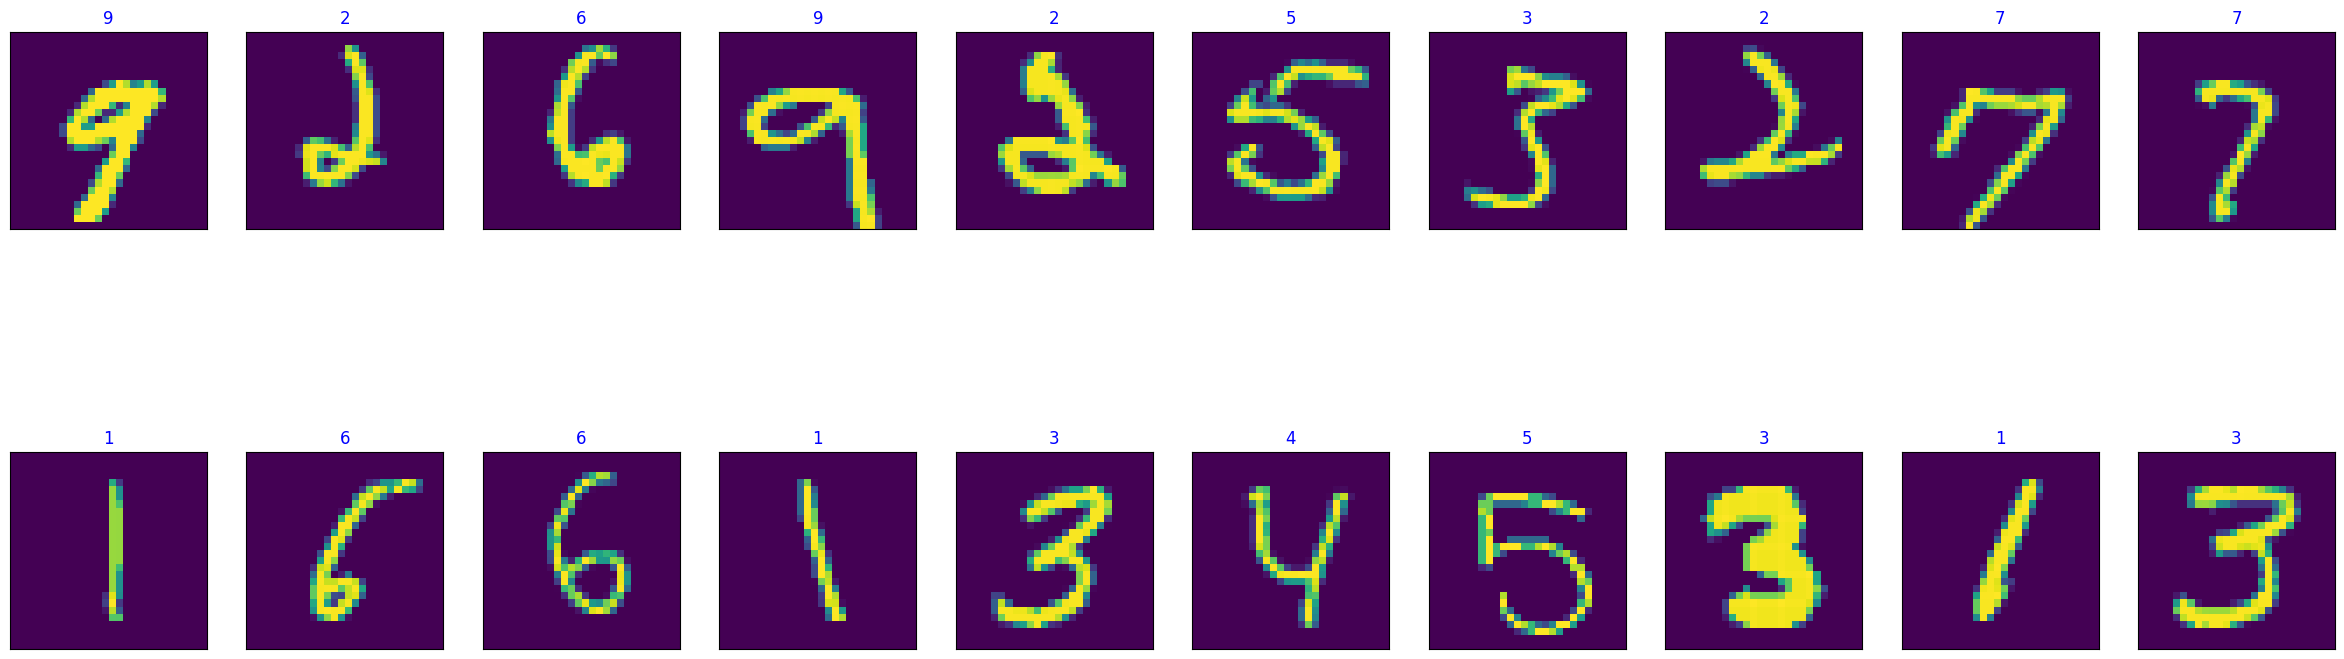

In [7]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

In [8]:
# Function to add Gaussian Noise

import torch

def add_noise(images, noise_factor=0.4):
    """
    Adds Gaussian noise to images.

    Parameters:
        images (Tensor): Input batch of images.
        noise_factor (float): Controls the amount of Gaussian noise.

    Returns:
        Tensor: Noisy images clipped between 0 and 1.
    """
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

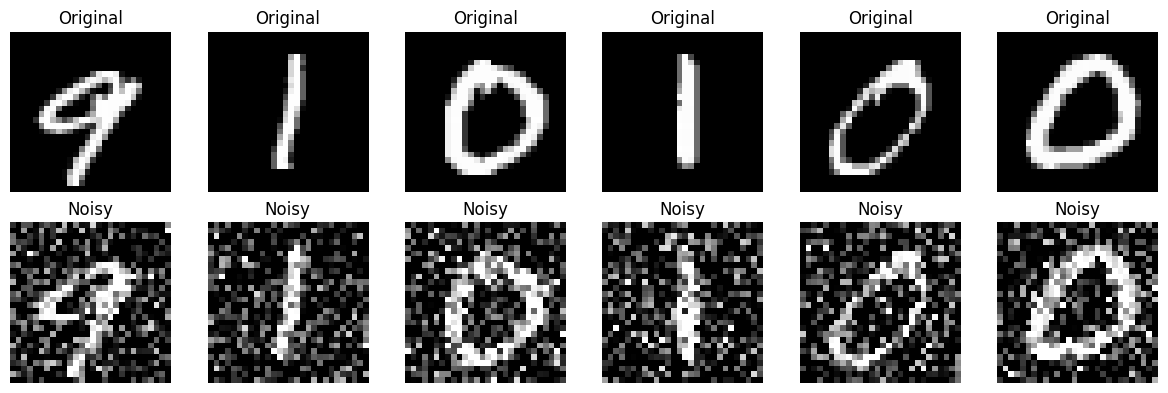

In [9]:
# Visualizing Original and Noisy Images

images, labels = next(iter(train_loader))

noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):

    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Defining Architecture

In [10]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.upsample(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [11]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [12]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [13]:
def trainNet(model, lr, state='fully'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Number of epochs
    loss_keeper = {'train': [], 'valid': []}
    epochs = 20

    # Minimum validation loss
    valid_loss_min = np.inf

    for epoch in range(epochs):

        train_loss = 0.0
        valid_loss = 0.0

        """
        TRAINING PHASE
        """
        model.train()

        for images, _ in train_loader:

            if use_cuda and torch.cuda.is_available():
                images = images.cuda()

            # Keep clean images as target
            clean_images = images.clone()

            # Add Gaussian noise
            noisy_images = add_noise(clean_images)

            # Flatten only for Fully Connected Autoencoder
            if state == 'fully':
                noisy_images = noisy_images.view(noisy_images.size(0), -1)
                clean_images = clean_images.view(clean_images.size(0), -1)

            optimizer.zero_grad()

            # Feed noisy image
            output = model(noisy_images)

            # Compare with clean image
            loss = criterion(output, clean_images)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        """
        VALIDATION PHASE
        """
        model.eval()

        with torch.no_grad():

            for images, _ in valid_loader:

                if use_cuda and torch.cuda.is_available():
                    images = images.cuda()

                clean_images = images.clone()

                noisy_images = add_noise(clean_images)

                if state == 'fully':
                    noisy_images = noisy_images.view(noisy_images.size(0), -1)
                    clean_images = clean_images.view(clean_images.size(0), -1)

                output = model(noisy_images)

                loss = criterion(output, clean_images)

                valid_loss += loss.item()

        # Average losses
        train_loss = train_loss / len(train_loader)
        valid_loss = valid_loss / len(valid_loader)

        # Store losses
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss:.6f}\tValidation Loss : {valid_loss:.6f}")

        # Save best model
        if valid_loss <= valid_loss_min:

            print(f"Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}). Saving model...")

            model_name = type(model).__name__

            torch.save(model.state_dict(), model_name + '_model.pth')

            valid_loss_min = valid_loss

    return loss_keeper

In [14]:
m1_loss=trainNet(model_1,0.001)


Epoch : 1	Training Loss : 0.045080	Validation Loss : 0.031424
Validation loss decreased (inf --> 0.031424). Saving model...

Epoch : 2	Training Loss : 0.028887	Validation Loss : 0.027473
Validation loss decreased (0.031424 --> 0.027473). Saving model...

Epoch : 3	Training Loss : 0.026716	Validation Loss : 0.026506
Validation loss decreased (0.027473 --> 0.026506). Saving model...

Epoch : 4	Training Loss : 0.026129	Validation Loss : 0.026165
Validation loss decreased (0.026506 --> 0.026165). Saving model...

Epoch : 5	Training Loss : 0.025884	Validation Loss : 0.025866
Validation loss decreased (0.026165 --> 0.025866). Saving model...

Epoch : 6	Training Loss : 0.025675	Validation Loss : 0.025739
Validation loss decreased (0.025866 --> 0.025739). Saving model...

Epoch : 7	Training Loss : 0.025481	Validation Loss : 0.025589
Validation loss decreased (0.025739 --> 0.025589). Saving model...

Epoch : 8	Training Loss : 0.025321	Validation Loss : 0.025418
Validation loss decreased (0.025

In [15]:
m2_loss=trainNet(model_2,0.001,'conv')


Epoch : 1	Training Loss : 0.039707	Validation Loss : 0.025614
Validation loss decreased (inf --> 0.025614). Saving model...

Epoch : 2	Training Loss : 0.023411	Validation Loss : 0.022205
Validation loss decreased (0.025614 --> 0.022205). Saving model...

Epoch : 3	Training Loss : 0.021525	Validation Loss : 0.021248
Validation loss decreased (0.022205 --> 0.021248). Saving model...

Epoch : 4	Training Loss : 0.020892	Validation Loss : 0.020920
Validation loss decreased (0.021248 --> 0.020920). Saving model...

Epoch : 5	Training Loss : 0.020485	Validation Loss : 0.020478
Validation loss decreased (0.020920 --> 0.020478). Saving model...

Epoch : 6	Training Loss : 0.020234	Validation Loss : 0.020344
Validation loss decreased (0.020478 --> 0.020344). Saving model...

Epoch : 7	Training Loss : 0.020006	Validation Loss : 0.020129
Validation loss decreased (0.020344 --> 0.020129). Saving model...

Epoch : 8	Training Loss : 0.019884	Validation Loss : 0.019870
Validation loss decreased (0.020

In [16]:
m3_loss=trainNet(model_3,0.001,'conv')

/tmp/ipykernel_2587/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_2587/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')



Epoch : 1	Training Loss : 0.029210	Validation Loss : 0.018528
Validation loss decreased (inf --> 0.018528). Saving model...

Epoch : 2	Training Loss : 0.017127	Validation Loss : 0.016314
Validation loss decreased (0.018528 --> 0.016314). Saving model...

Epoch : 3	Training Loss : 0.015953	Validation Loss : 0.015663
Validation loss decreased (0.016314 --> 0.015663). Saving model...

Epoch : 4	Training Loss : 0.015476	Validation Loss : 0.015310
Validation loss decreased (0.015663 --> 0.015310). Saving model...

Epoch : 5	Training Loss : 0.015143	Validation Loss : 0.015067
Validation loss decreased (0.015310 --> 0.015067). Saving model...

Epoch : 6	Training Loss : 0.014908	Validation Loss : 0.014829
Validation loss decreased (0.015067 --> 0.014829). Saving model...

Epoch : 7	Training Loss : 0.014731	Validation Loss : 0.014769
Validation loss decreased (0.014829 --> 0.014769). Saving model...

Epoch : 8	Training Loss : 0.014629	Validation Loss : 0.014514
Validation loss decreased (0.014

In [17]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

## Plotting Loss

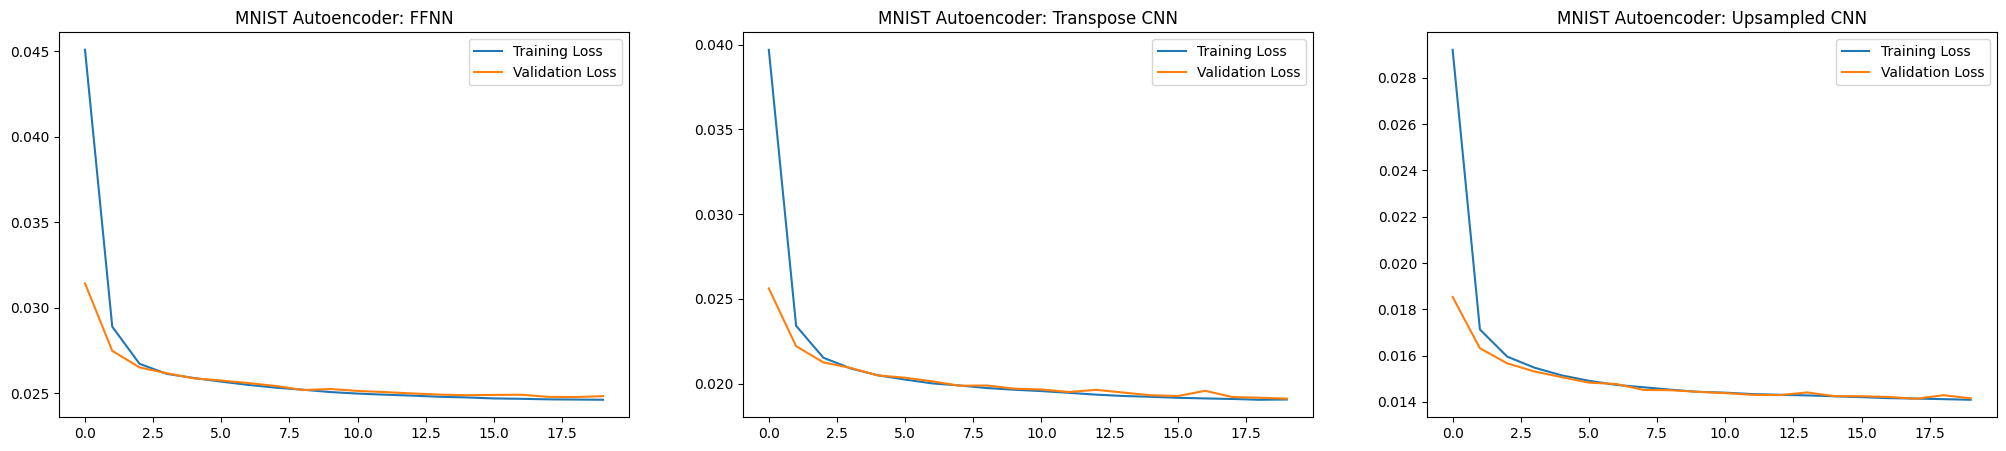

In [18]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [19]:
def test(model, state='fully'):

    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    # Keep clean images
    clean_images = images.clone()

    # Add Gaussian noise
    noisy_images = add_noise(clean_images)

    if state == 'fully':
        noisy_images = noisy_images.view(noisy_images.size(0), -1)

    # Get denoised output
    model.eval()
    with torch.no_grad():
        output = model(noisy_images)

    # Prepare images for display
    clean_images = clean_images.cpu().numpy()

    output = output.view(batch_size, 1, 28, 28)
    output = output.cpu().numpy()

    # Plot original and denoised images
    fig, axes = plt.subplots(nrows=2,
                             ncols=10,
                             sharex=True,
                             sharey=True,
                             figsize=(25,4))

    # Original images on top, denoised on bottom
    for images, row in zip([clean_images, output], axes):
        for img, ax in zip(images, row):

            if state == 'fully':
                img = img.reshape(1, 28, 28)

            ax.imshow(np.squeeze(img), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

    plt.show()


## FFNN Autoencoder

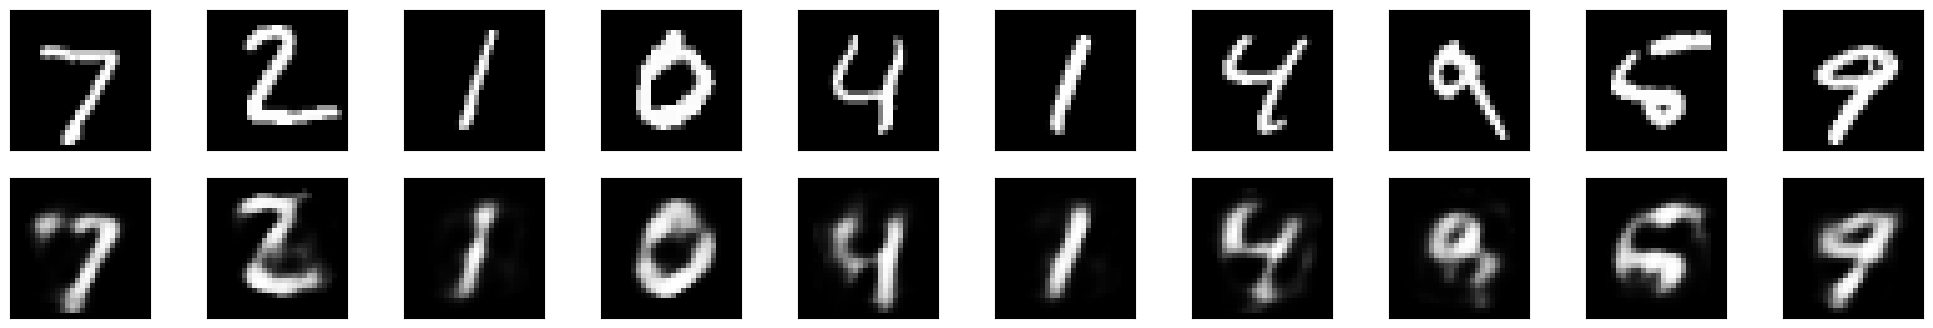

In [20]:
test(model_1)

## Transpose CNN Autoencoder

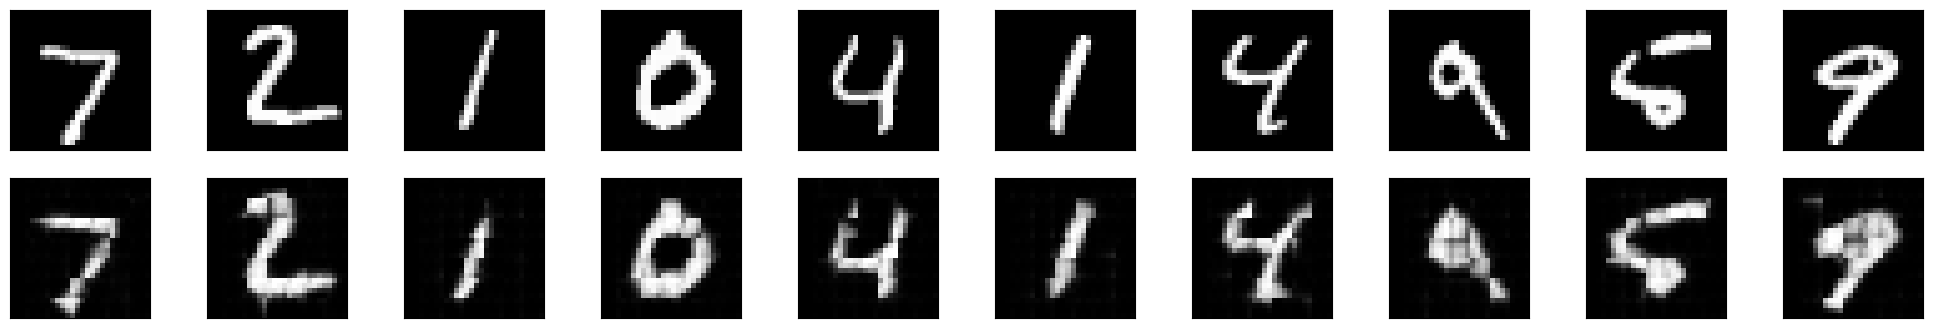

In [21]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

/tmp/ipykernel_2587/219568314.py:42: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')
/tmp/ipykernel_2587/219568314.py:44: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x = F.upsample(x, scale_factor=2, mode='nearest')


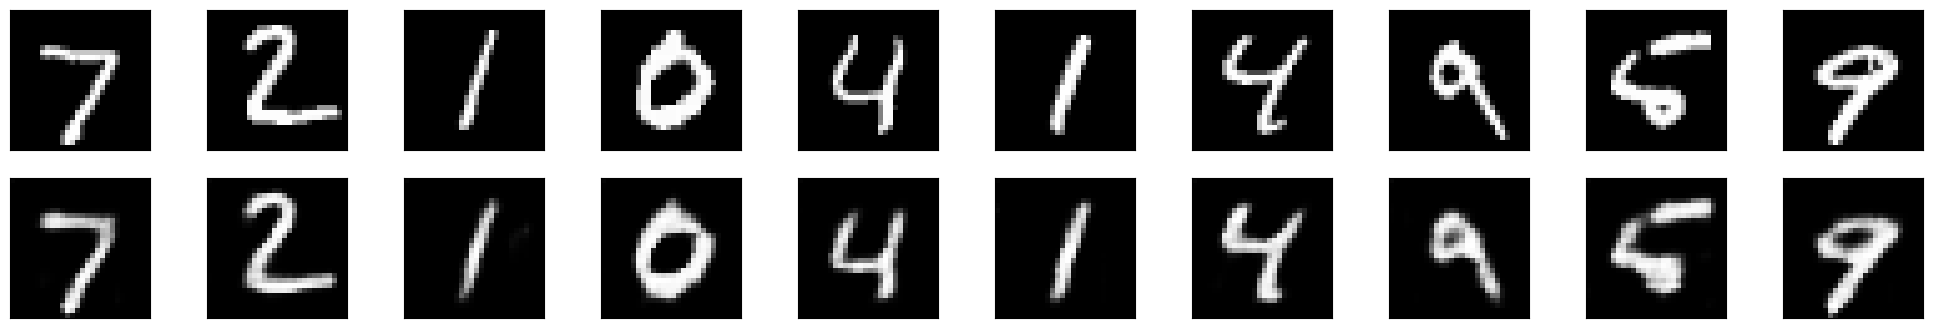

In [22]:
test(model_3,'conv')

**Observations:**

• The training and validation losses decreased steadily over the epochs, indicating successful learning.

• The autoencoder effectively removed Gaussian noise while preserving the digit structure.

• Convolution-based autoencoders produced sharper reconstructions compared to the fully connected autoencoder.

• The denoised images closely resembled the original clean images, demonstrating good reconstruction performance.

**Conclusion:**
A denoising autoencoder was successfully implemented and trained on the MNIST dataset. The model learned to reconstruct clean images from noisy inputs. Among the tested architectures, convolutional autoencoders produced better-quality reconstructions, showing that convolutional layers are more effective for image denoising tasks.